In [40]:
import ROOT
ROOT.gSystem.Load("libBambooRandom")
from bamboo_hh.plotter.plotter import Plotter
from bamboo_hh.definitions import variables 
import bisect
import mplhep as hep
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate
from pathlib import Path
from dataclasses import dataclass, field

hep.style.use("CMS")

In [41]:
@dataclass
class EffiVar:
    name: str
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    title: str

effivars = [
    EffiVar('pt', 0, 0, 200, 1.1, ";Electron p_{T} (GeV);Efficiency"),
    # EffiVar('eta', -3, 0, 3, 1.1, ";Muon #eta;Efficiency"),
    # EffiVar('HT', 0, 0, 1000, 1.1, ";HT (GeV);Efficiency"),
    # EffiVar('npv', 0, 0, 100, 1.1, ";Nr. of Primary Vertices;Efficiency"),
    # EffiVar('npv_good', 0, 0, 100, 1.1, ";Nr. of Good Primary Vertices;Efficiency")
]

@dataclass
class Selection:
    name: str
    label: str
    input_file: ROOT.TFile
    hist: dict[str, ROOT.TH1] = field(default_factory=dict)
    effi: ROOT.TEfficiency = field(default=None)
    def __post_init__(self):
        self.hist = {effivar.name: input_file.Get(f'{self.name}_{effivar.name}') for effivar in effivars}

In [42]:
def extract_tefficiency(teff):
    hist = teff.GetTotalHistogram()
    n_bins = hist.GetNbinsX()
    data = [
        (
            hist.GetBinCenter(i),
            hist.GetBinWidth(i),
            teff.GetEfficiency(i),
            teff.GetEfficiencyErrorLow(i),
            teff.GetEfficiencyErrorUp(i)
        )
        for i in range(1, n_bins + 1)
    ]
    bin_centers, bin_widths, effs, err_low, err_up = map(np.array, zip(*data))
    valid = ~np.isnan(effs) & ~np.isnan(err_low) & ~np.isnan(err_up) & (effs > 0)
    return bin_centers[valid], bin_widths[valid], effs[valid], err_low[valid], err_up[valid]

In [ ]:
def plot_mu_paths_plt(input_file, outdir, plot_dist: bool):
    OR_of_existing = Selection("SL_mu_HLT_All", "OR of existing triggers", input_file)
    New_trigger_ORed = Selection("SL_mu_HLT_Mu12_IsoVVL_PFHT150_PNetBTag_0p53_OR_All", "New trigger OR'ed with existing triggers", input_file)
    denominator_selection = Selection("SL_mu", "No triggers", input_file)

    pt_var = effivars[0]

    plt.figure(figsize=(10, 8))
    plt.xlabel("Muon $p_T$ [GeV]", fontsize=30)
    plt.ylabel("Efficiency", fontsize=30)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.ylim(0, 1.1)
    plt.xlim(0,200)
    plt.grid(True)

    # First efficiency curve
    OR_of_existing.effi = ROOT.TEfficiency(OR_of_existing.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers, bin_widths, efficiencies, lower_errors, upper_errors = extract_tefficiency(OR_of_existing.effi)
    plt.errorbar(bin_centers, efficiencies,
        xerr=bin_widths / 2, yerr=[lower_errors, upper_errors],
        fmt='o', color='peru', label=OR_of_existing.label,
        markersize=1, capsize=2
    )
    # Second efficiency curve
    New_trigger_ORed.effi = ROOT.TEfficiency(New_trigger_ORed.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers2, bin_widths2, efficiencies2, lower_errors2, upper_errors2 = extract_tefficiency(New_trigger_ORed.effi)
    plt.errorbar(bin_centers2, efficiencies2,
        xerr=bin_widths2 / 2,yerr=[lower_errors2, upper_errors2],
        fmt='o', color='red', label=New_trigger_ORed.label,
        markersize=1, capsize=2
    )

    if plot_dist:
        # Add pt distribution
        pt_hist = input_file.Get(f"SL_mu_{pt_var.name}_Uniform4")
        n_bins = pt_hist.GetNbinsX()
        bin_edges = np.array([pt_hist.GetBinLowEdge(i + 1) for i in range(n_bins)] + [pt_hist.GetBinLowEdge(n_bins + 1)])
        bin_contents = np.array([pt_hist.GetBinContent(i + 1) for i in range(n_bins)])
        bin_contents_norm = bin_contents / np.max(bin_contents) * 0.2
        plt.bar(
            bin_edges[:-1],                
            bin_contents_norm,              
            width=np.diff(bin_edges),       
            align='edge',
            color='gray',
            alpha=0.6,
            label='Pre-trigger distribution'
        )

    plt.legend(loc='center right', fontsize=20, frameon=True, edgecolor="black", )
    hep.cms.label("Preliminary", data=False, com="13.6")
    plt.tight_layout()
    plt.savefig(f"{outdir}/SL_mu_effi_{pt_var.name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
def plot_e_paths_plt(input_file, outdir, plot_dist: bool):
    OR_of_existing = Selection("SL_e_HLT_All", "OR of existing triggers", input_file)
    New_trigger_ORed = Selection("SL_e_HLT_Ele14_eta2p5_IsoVVVL_Gsf_HT200_PNetBTag_0p53_OR_All", "New trigger OR'ed with existing triggers", input_file)
    denominator_selection = Selection("SL_e", "No triggers", input_file)

    pt_var = effivars[0]

    plt.figure(figsize=(10, 8))
    plt.xlabel("Electron $p_T$ [GeV]", fontsize=30)
    plt.ylabel("Efficiency", fontsize=30)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.ylim(0, 1.1)
    plt.xlim(0,200)
    plt.grid(True)

    # First efficiency curve
    OR_of_existing.effi = ROOT.TEfficiency(OR_of_existing.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers, bin_widths, efficiencies, lower_errors, upper_errors = extract_tefficiency(OR_of_existing.effi)
    plt.errorbar(bin_centers, efficiencies,
        xerr=bin_widths / 2, yerr=[lower_errors, upper_errors],
        fmt='o', color='peru', label=OR_of_existing.label,
        markersize=1, capsize=2
    )

    # Second efficiency curve
    New_trigger_ORed.effi = ROOT.TEfficiency(New_trigger_ORed.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers2, bin_widths2, efficiencies2, lower_errors2, upper_errors2 = extract_tefficiency(New_trigger_ORed.effi)
    plt.errorbar(bin_centers2, efficiencies2,
        xerr=bin_widths2 / 2, yerr=[lower_errors2, upper_errors2],
        fmt='o', color='red', label=New_trigger_ORed.label,
        markersize=1,capsize=2
    )

    if plot_dist:
        # Add pt distribution
        pt_hist = input_file.Get(f'SL_e_{pt_var.name}_Uniform4')
        n_bins = pt_hist.GetNbinsX()
        bin_edges = np.array([pt_hist.GetBinLowEdge(i + 1) for i in range(n_bins)] + [pt_hist.GetBinLowEdge(n_bins + 1)])
        bin_contents = np.array([pt_hist.GetBinContent(i + 1) for i in range(n_bins)])
        bin_contents_norm = bin_contents / np.max(bin_contents) * 0.2  # scale to max=0.4
        plt.bar(bin_edges[:-1], bin_contents_norm, width=np.diff(bin_edges),       
            align='edge', color='gray', alpha=0.6,
            label='Pre-trigger distribution'
        )

    plt.legend(loc='center right', fontsize=20, frameon=True, edgecolor="black", )
    hep.cms.label("Preliminary", data=False, com="13.6")
    plt.tight_layout()
    plt.savefig(f"{outdir}/SL_e_effi_{pt_var.name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

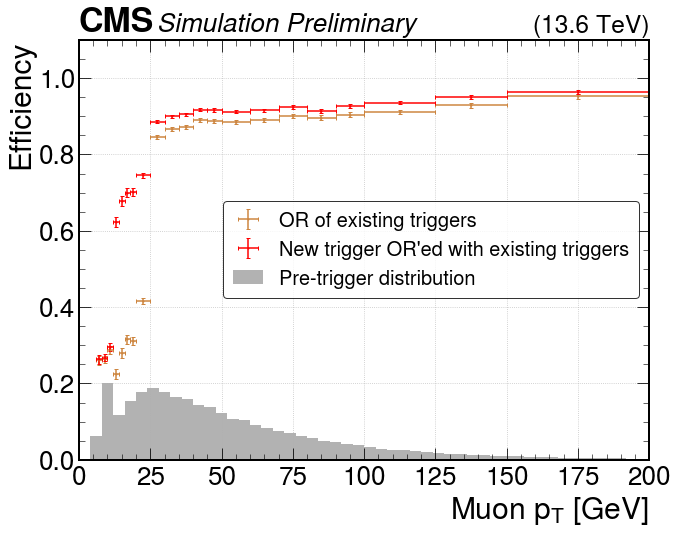

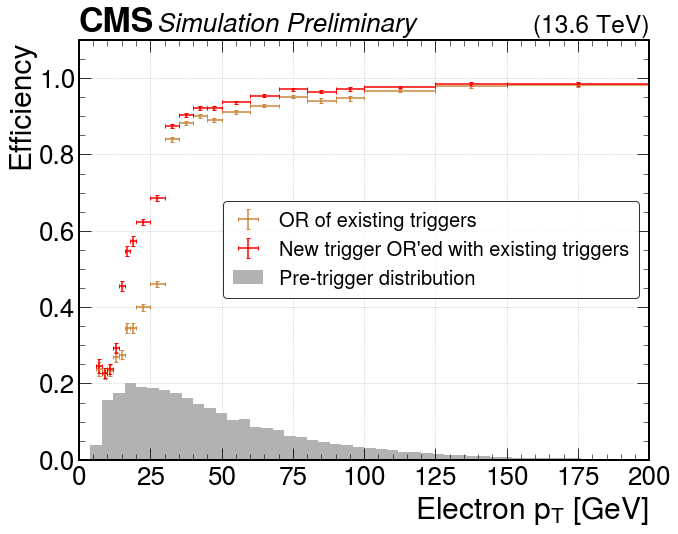

In [ ]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_HLT_7GeV')
signal_file = workdir / 'results' / 'bbWW_sl.root'
input_file = ROOT.TFile.Open(str(signal_file))

outdir = workdir / 'Effi_plots_w_dist'
outdir.mkdir(parents=True, exist_ok=True)
plot_mu_paths_plt(input_file, outdir, plot_dist=True)
plot_e_paths_plt(input_file, outdir, plot_dist=True)

outdir = workdir / 'Effi_plots'
outdir.mkdir(parents=True, exist_ok=True)
plot_mu_paths_plt(input_file, outdir, plot_dist=False)
plot_e_paths_plt(input_file, outdir, plot_dist=False)